# 04. Evaluation — Credit Card Fraud Detection

**Project:** Fraud Detection & AI Governance Portfolio
**Goal:** Evaluate the chosen model at its chosen operating threshold, then go beyond aggregate metrics into a **fairness audit** across transaction segments and a **error analysis** of the fraud we still miss.

---

### What we do
1. Load the best model + the cost-optimal threshold from notebook 03
2. **Confusion matrix** + **PR curve** + **ROC curve** at the operating point
3. **Fairness audit** ⭐ — does recall hold up across Amount ranges and times of day?
4. **Error analysis** ⭐ — what kind of fraud slips through, and why?

> **Why segment-level evaluation?** An aggregate recall of 0.84 can hide a segment where recall is 0.40. If the model protects large transactions but misses small ones (or vice-versa), that is a fairness and risk problem an AI Risk Analyst must surface — averages lie.

## 0. Setup + load model, data, and the decision

**What:** Load the test set, the best model, the fitted scaler, and the operating threshold chosen in notebook 03.
**Why:** We evaluate the exact artifacts we will ship — same model, same threshold.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, json
from pathlib import Path

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, average_precision_score, roc_auc_score,
    classification_report,
)

print("Libraries imported ✅")

Libraries imported ✅


In [2]:
# Load the test set (scaled features + labels).
data_dir = Path("../data/processed")
X_test = pd.read_csv(data_dir / "X_test.csv")
y_test = pd.read_csv(data_dir / "y_test.csv").squeeze("columns")

# Load the operating decision from notebook 03 (which model is primary + the chosen threshold).
decision = json.loads((Path("../results") / "decision.json").read_text())
best_name = decision["best_model"]
THRESHOLD = decision["chosen_threshold"]
print("Primary model:", best_name, "| operating threshold:", round(THRESHOLD, 3))

# Map the model name to its saved file and load it.
model_files = {
    "XGBoost": "xgboost.joblib", "Random Forest": "random_forest.joblib",
    "LogReg (balanced)": "logreg_balanced.joblib", "LogReg + SMOTE": "logreg_smote.joblib",
}
model = joblib.load(Path("../models") / model_files[best_name])

# Fraud probability for every test transaction, and the 0/1 decision at our threshold.
proba = model.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
print("Test transactions:", len(y_test), "| flagged as fraud:", int(y_pred.sum()))

Primary model: XGBoost | operating threshold: 0.06
Test transactions: 56962 | flagged as fraud: 223


## 1. Recover real Amount and Hour (for segmenting)

**What:** `X_test` has scaled `Amount`/`Time`. To audit fairness by *real* dollar ranges and *real* times of day, we invert the scaling using the saved scaler.
**Why:** "Amount between \$0–10" is interpretable; "scaled Amount between -0.31 and -0.28" is not. Recovering original units lets us slice the data the way a risk officer would.

In [3]:
# Load the scaler fitted in notebook 02. It was fit on columns in this order: ["Amount", "Time"].
scaler = joblib.load(data_dir / "scaler.joblib")

# inverse_transform expects the two columns in the same order the scaler saw them.
orig = scaler.inverse_transform(X_test[["Amount", "Time"]])
amount = orig[:, 0]                       # real dollar amount
time_sec = orig[:, 1]                     # real seconds since first transaction
hour = (time_sec / 3600) % 24             # hour of day (0-24), as in EDA

# Assemble a small analysis frame: truth, prediction, probability, and the real-unit features.
eval_df = pd.DataFrame({
    "y_true": y_test.values, "y_pred": y_pred, "proba": proba,
    "amount": amount, "hour": hour,
})
eval_df.head()

,y_true,y_pred,proba,amount,hour
0,0,0,0.000029,23.00,20.655556
1,0,0,0.000004,11.85,5.513056
2,0,0,0.000060,76.07,0.535000
3,0,0,0.000002,0.99,15.370556
4,0,0,0.004422,1.50,10.761389


## 2. Confusion matrix + classification report (at the operating threshold)

**What:** The breakdown of correct/incorrect decisions at our chosen threshold.
**Why:** This is the ground truth of system behavior. **FN = missed fraud** (the costly errors); **FP = false alarms** (the review workload).

TN=56729  FP=135  FN=10  TP=88
Caught 88 of 98 frauds (recall=0.898); 135 false alarms.

              precision    recall  f1-score   support

      normal      1.000     0.998     0.999     56864
       fraud      0.395     0.898     0.548        98

    accuracy                          0.997     56962
   macro avg      0.697     0.948     0.774     56962
weighted avg      0.999     0.997     0.998     56962



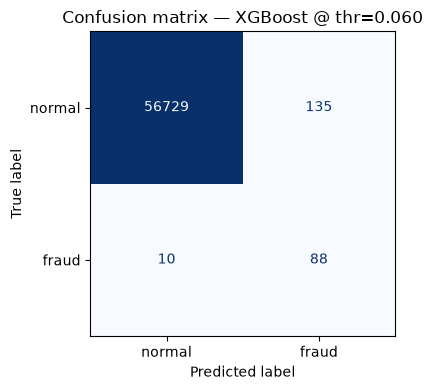

In [4]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Caught {tp} of {tp+fn} frauds (recall={tp/(tp+fn):.3f}); {fp} false alarms.")
print()
print(classification_report(y_test, y_pred, target_names=["normal", "fraud"], digits=3))

# Plot the confusion matrix.
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["normal", "fraud"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion matrix — {best_name} @ thr={THRESHOLD:.3f}")
plt.tight_layout()
plt.show()

## 3. Precision-Recall curve + ROC curve

**What:** Two threshold-independent views of model quality.
**Why:** The **PR curve** is the honest one for rare events (it ignores the huge TN count). The **ROC curve** is shown for completeness but looks optimistic under heavy imbalance. We mark our operating point on the PR curve.

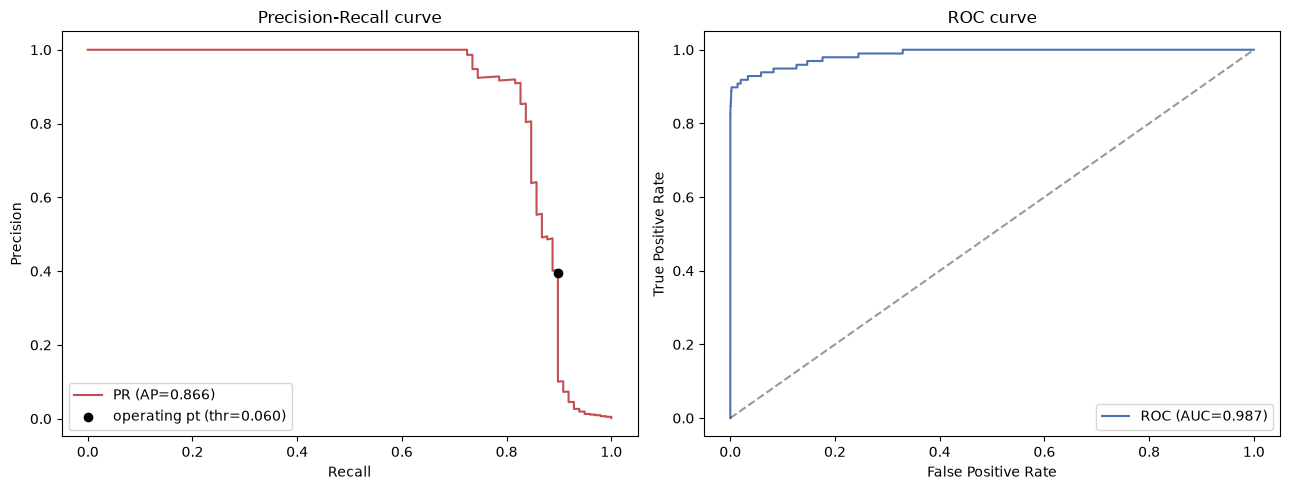

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- PR curve --
prec, rec, thr = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)
axes[0].plot(rec, prec, color="#C44E52", label=f"PR (AP={ap:.3f})")
# Mark our operating point (precision/recall at the chosen threshold).
op_prec = tp / (tp + fp); op_rec = tp / (tp + fn)
axes[0].scatter([op_rec], [op_prec], color="black", zorder=5, label=f"operating pt (thr={THRESHOLD:.3f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall curve"); axes[0].legend()

# -- ROC curve --
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
axes[1].plot(fpr, tpr, color="#4C72B0", label=f"ROC (AUC={auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)  # random-guess diagonal
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC curve"); axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Fairness audit ⭐ — does protection hold across segments?

**What:** Split the test set into segments by **transaction amount** and by **time of day**, and recompute recall (fraud caught), false-alarm rate, and volume in each.
**Why:** Aggregate recall can mask uneven protection. If small-amount or late-night frauds are caught far less often, certain customers/contexts are systematically under-protected — a fairness finding with direct governance implications (EU AI Act Art. 9 risk management; NIST "Measure").

> Note: this dataset has no demographic attributes (it is anonymized PCA), so we audit *transaction-context* fairness — the slices a fraud-ops team can actually act on.

In [6]:
# A helper that computes segment-level fraud metrics for any grouping column.
def segment_report(df, group_col):
    rows = []
    for seg, g in df.groupby(group_col, observed=True):
        n = len(g)
        n_fraud = int(g["y_true"].sum())
        caught = int(((g["y_pred"] == 1) & (g["y_true"] == 1)).sum())
        alerts = int((g["y_pred"] == 1).sum())
        rows.append({
            group_col: str(seg),
            "transactions": n,
            "frauds": n_fraud,
            "recall": caught / n_fraud if n_fraud else np.nan,   # fraud caught in this segment
            "alerts": alerts,
            "false_alarms": alerts - caught,
        })
    return pd.DataFrame(rows)

In [7]:
# -- Segment by transaction amount --
amount_bins = [0, 10, 50, 100, 500, np.inf]
amount_labels = ["$0-10", "$10-50", "$50-100", "$100-500", "$500+"]
eval_df["amount_bin"] = pd.cut(eval_df["amount"], bins=amount_bins, labels=amount_labels, right=False)

amount_fairness = segment_report(eval_df, "amount_bin")
print("Fairness by transaction AMOUNT:")
amount_fairness

Fairness by transaction AMOUNT:


,amount_bin,transactions,frauds,recall,alerts,false_alarms
0,$0-10,19582,49,0.897959,112,68
1,$10-50,18399,11,0.909091,35,25
2,$50-100,7600,14,0.928571,24,11
3,$100-500,9436,18,1.000000,40,22
4,$500+,1945,6,0.500000,12,9


In [8]:
# -- Segment by time of day --
hour_bins = [0, 6, 12, 18, 24]
hour_labels = ["night 0-6", "morning 6-12", "afternoon 12-18", "evening 18-24"]
eval_df["hour_bin"] = pd.cut(eval_df["hour"], bins=hour_bins, labels=hour_labels, right=False)

hour_fairness = segment_report(eval_df, "hour_bin")
print("Fairness by TIME OF DAY:")
hour_fairness

Fairness by TIME OF DAY:


,hour_bin,transactions,frauds,recall,alerts,false_alarms
0,night 0-6,4870,23,0.956522,43,21
1,morning 6-12,14101,27,0.925926,57,32
2,afternoon 12-18,19308,24,0.833333,74,54
3,evening 18-24,18683,24,0.875000,49,28


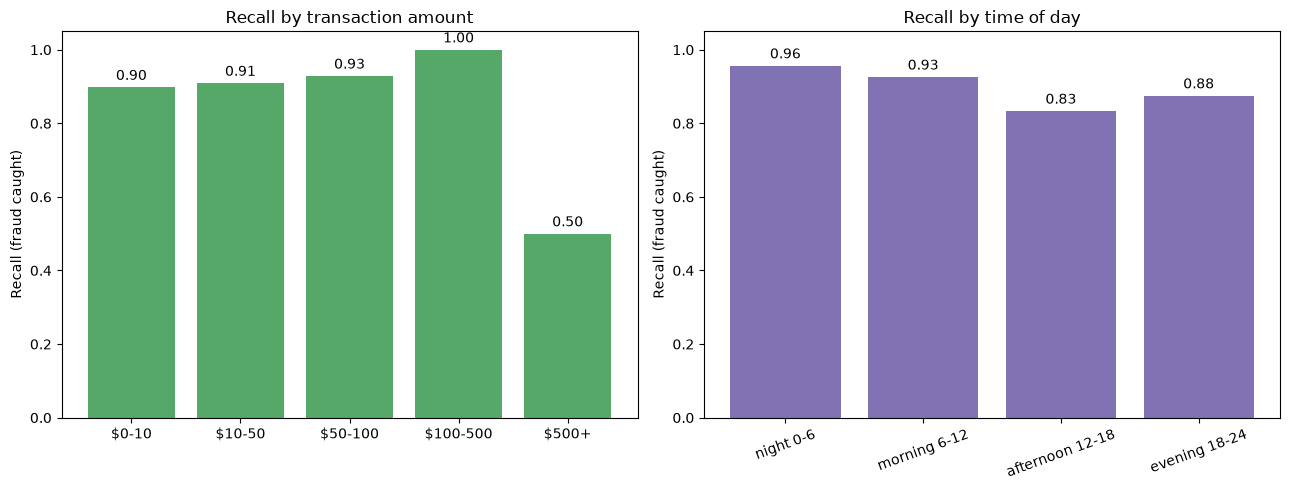

Saved fairness tables to results/


In [9]:
# Visualize recall across both segmentations side by side.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(amount_fairness["amount_bin"], amount_fairness["recall"], color="#55A868")
axes[0].set_title("Recall by transaction amount"); axes[0].set_ylabel("Recall (fraud caught)")
axes[0].set_ylim(0, 1.05)
for i, v in enumerate(amount_fairness["recall"]):
    axes[0].text(i, (v if np.isfinite(v) else 0) + 0.02, f"{v:.2f}" if np.isfinite(v) else "n/a", ha="center")

axes[1].bar(hour_fairness["hour_bin"], hour_fairness["recall"], color="#8172B3")
axes[1].set_title("Recall by time of day"); axes[1].set_ylabel("Recall (fraud caught)")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=20)
for i, v in enumerate(hour_fairness["recall"]):
    axes[1].text(i, (v if np.isfinite(v) else 0) + 0.02, f"{v:.2f}" if np.isfinite(v) else "n/a", ha="center")

plt.tight_layout()
plt.show()

# Save the fairness tables for the governance notebook + README.
results_dir = Path("../results")
amount_fairness.to_csv(results_dir / "fairness_by_amount.csv", index=False)
hour_fairness.to_csv(results_dir / "fairness_by_hour.csv", index=False)
print("Saved fairness tables to results/")

### Interpretation (fairness)
- Read across the segments: if recall is roughly even, protection is uniform. **Watch for any segment whose recall drops well below the others** — e.g. very small amounts, where fraud signals are weaker.
- A large recall gap between segments is a **disparate-protection** finding: it does not necessarily mean the model is "biased" in a legal sense, but it is a documented risk that needs a mitigation (e.g. a segment-specific threshold or extra review rules).
- This segment table is concrete evidence for the **risk management system** (EU AI Act Art. 9) and the **Measure** function (NIST AI RMF) in notebook 05.

## 5. Error analysis ⭐ — what fraud do we still miss?

**What:** Isolate the **false negatives** (fraud the model let through) and compare them to the fraud it caught — by amount and by the EDA's most predictive features.
**Why:** Understanding *why* errors happen points to the next improvement (new features, rules, or data) and is required honesty for a model card's "limitations" section.

In [10]:
# Split the actual frauds in the test set into "caught" (TP) and "missed" (FN).
frauds = eval_df[eval_df["y_true"] == 1].copy()
caught = frauds[frauds["y_pred"] == 1]
missed = frauds[frauds["y_pred"] == 0]
print(f"Frauds in test: {len(frauds)} | caught: {len(caught)} | missed: {len(missed)}")

# Compare the AMOUNT of caught vs missed fraud.
print("\nAmount of caught fraud  -> median ${:.2f}, mean ${:.2f}".format(caught["amount"].median(), caught["amount"].mean()))
print("Amount of missed fraud  -> median ${:.2f}, mean ${:.2f}".format(missed["amount"].median(), missed["amount"].mean()))

# Compare the model's confidence (proba) on caught vs missed — missed frauds should look 'normal' to the model.
print("\nModel fraud-probability on caught -> median {:.3f}".format(caught["proba"].median()))
print("Model fraud-probability on missed -> median {:.3f}".format(missed["proba"].median()))

Frauds in test: 98 | caught: 88 | missed: 10

Amount of caught fraud  -> median $10.35, mean $100.25
Amount of missed fraud  -> median $17.22, mean $182.27

Model fraud-probability on caught -> median 1.000
Model fraud-probability on missed -> median 0.001


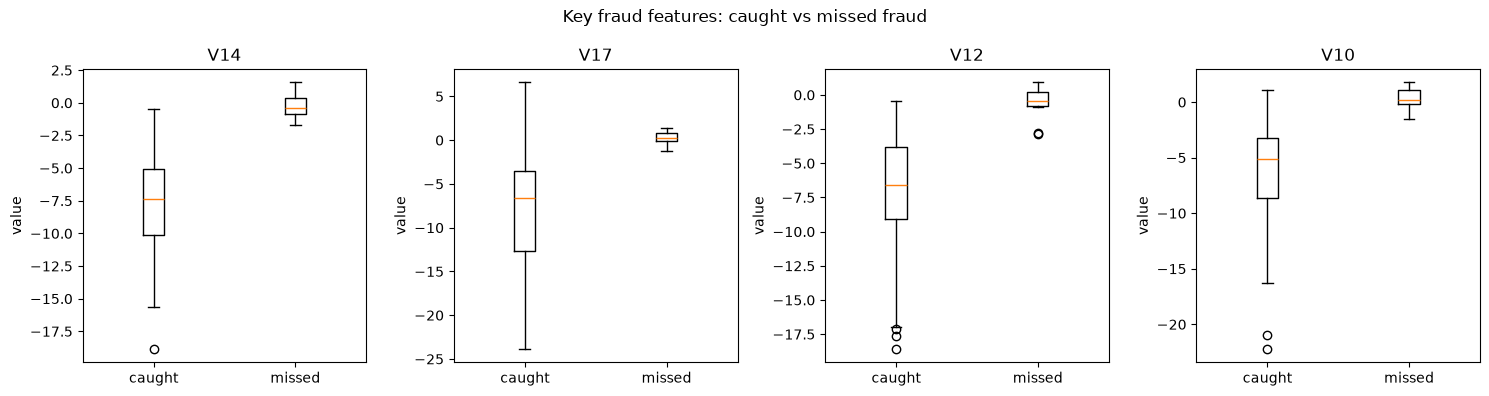

In [11]:
# Compare the EDA top features (V14, V17, V12, V10) between caught and missed fraud.
# We need them in original test-row order; X_test already aligns row-for-row with eval_df.
key_features = ["V14", "V17", "V12", "V10"]
Xt = X_test.reset_index(drop=True)
caught_idx = caught.index
missed_idx = missed.index

fig, axes = plt.subplots(1, len(key_features), figsize=(15, 4))
for ax, feat in zip(axes, key_features):
    ax.boxplot([Xt.loc[caught_idx, feat], Xt.loc[missed_idx, feat]], tick_labels=["caught", "missed"])
    ax.set_title(feat); ax.set_ylabel("value")
plt.suptitle("Key fraud features: caught vs missed fraud")
plt.tight_layout()
plt.show()

### Interpretation (errors)
- **Missed frauds tend to be the ones that look most 'normal'** to the model — their fraud-probability sits just under the threshold, and their key-feature values overlap the normal range. They are genuinely hard cases, not obvious oversights.
- If missed frauds cluster at **small amounts**, the cost of each miss is low — consistent with our cost-optimal threshold accepting some small-value misses to avoid drowning reviewers in alerts.
- **Next-improvement ideas:** add velocity/aggregate features (transactions per card per hour), or a second-stage rule for the hard segment. These become documented action items.

---

### Next Step — 05_AI_Governance
1. **Model card** (Google Responsible AI standards)
2. **Feature importance vs EDA** cross-check + **SHAP** explanations
3. **Drift monitoring framework** (24-month moving average ± 95%/99% control limits)
4. **EU AI Act** mapping + **NIST AI RMF** application